In [149]:
import torch
import matplotlib.pyplot as plt

In [150]:
with open("./names.txt", "r") as f:
    names = f.read().split()

len(names)

32033

In [151]:
stoi = {char: index + 1 for index, char in enumerate(sorted(list(set(''.join(names)))))}

stoi["."] = 0

itos = {value: key for key, value in stoi.items()}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [152]:
N = torch.zeros(size=(27, 27), dtype=torch.int32)
N.shape

torch.Size([27, 27])

In [153]:
counter = {}
for name in names:
    chs = ['.'] + list(name) + ['.']
    for c1, c2 in zip(chs, chs[1:]):
        i1, i2 = stoi[c1], stoi[c2]
        N[i1, i2] += 1


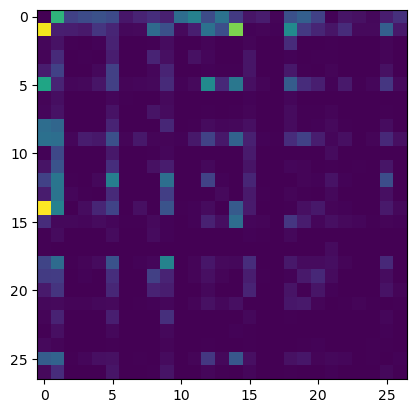

In [154]:
plt.imshow(N)

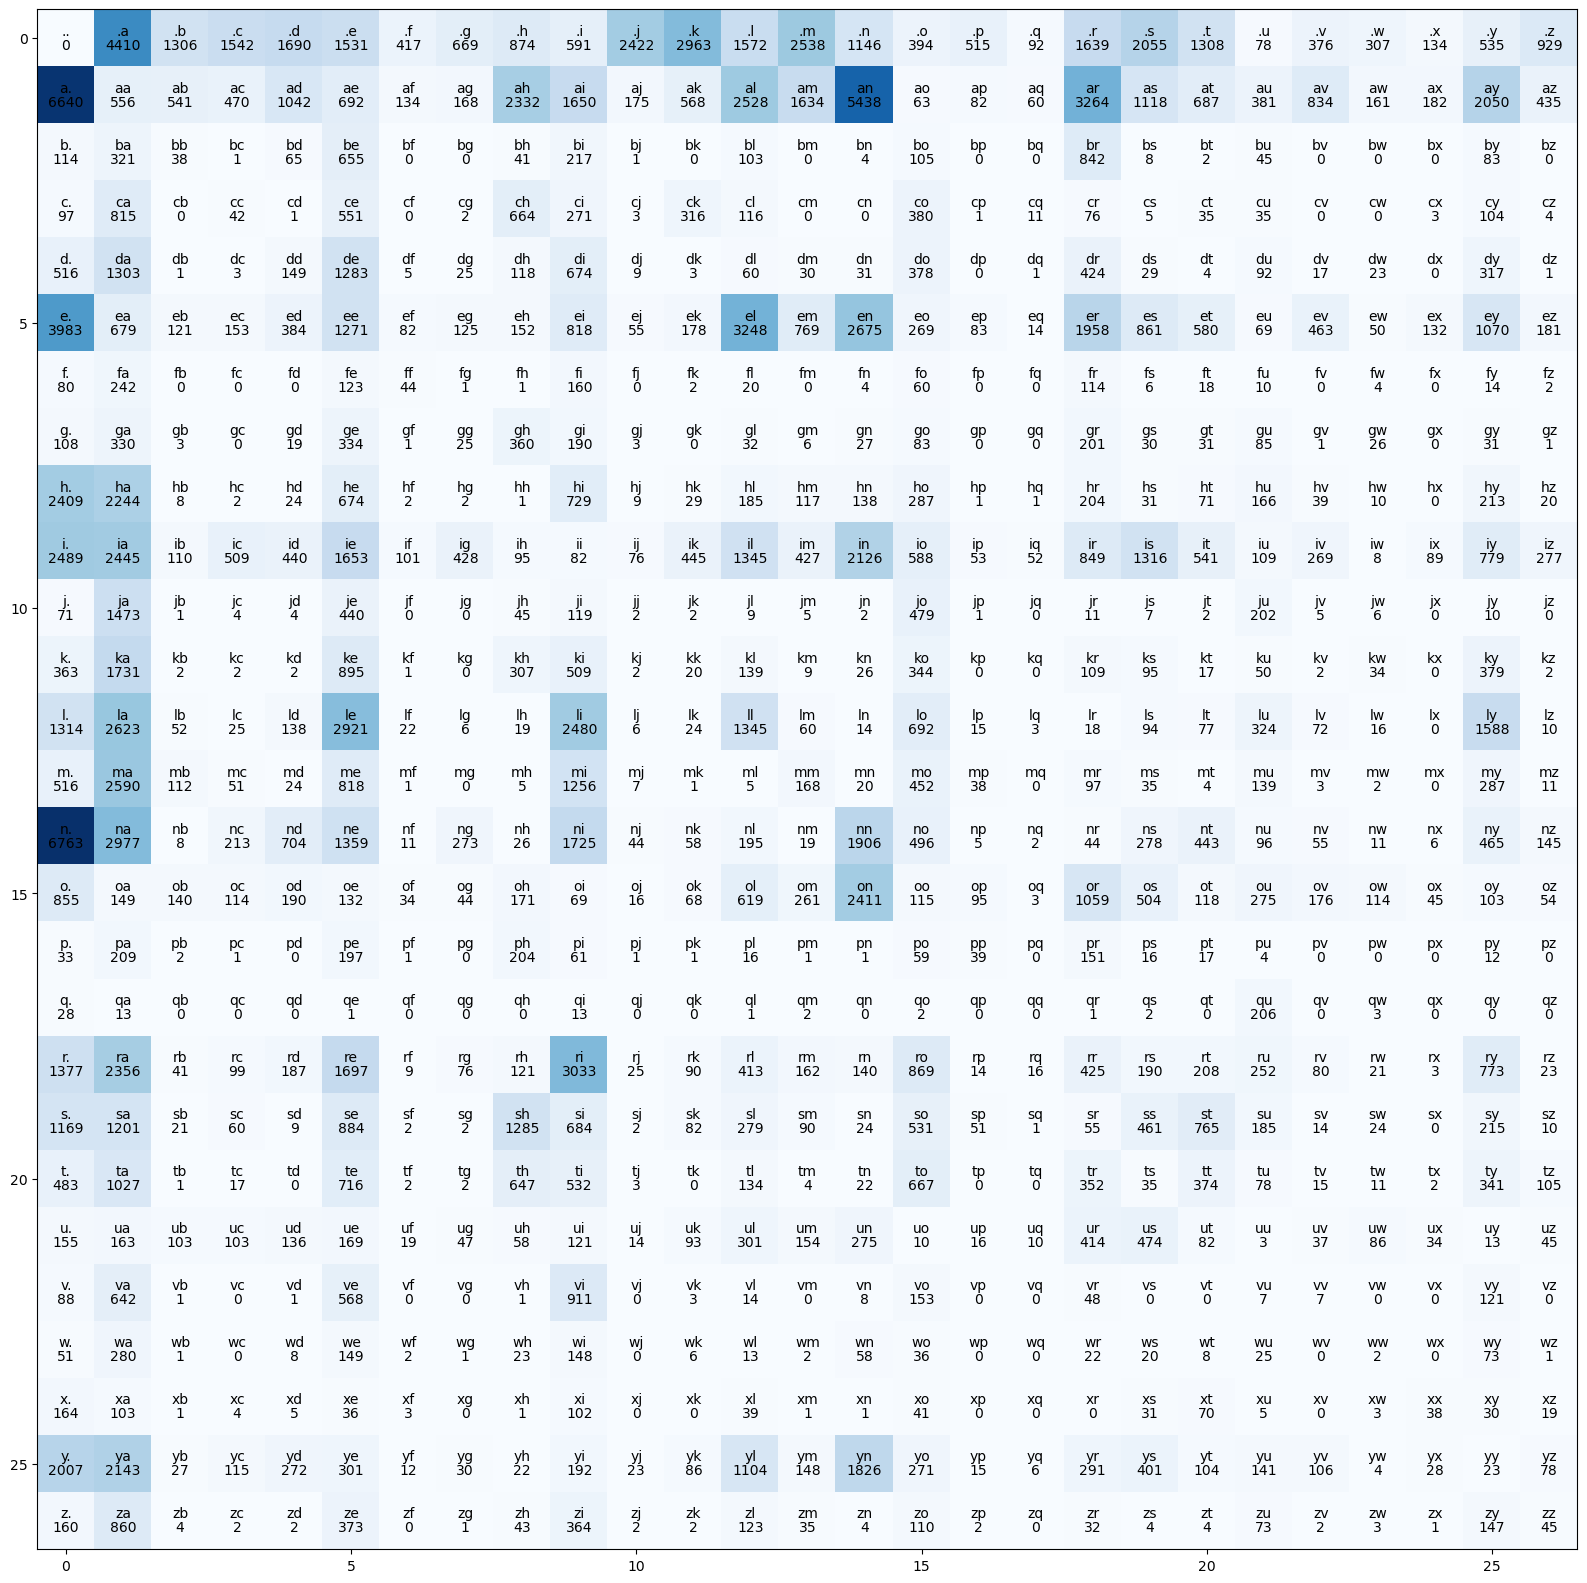

In [155]:
plt.figure(figsize=(20, 20))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        ch = itos[i] + itos[j]
        plt.text(j, i, ch, ha="center", va="bottom", color="black")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="black")

In [156]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [157]:
p = N[0].float()
p /= p.sum()
p


tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [158]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [159]:
P = N.float()
P /= P.sum(dim = 1, keepdim=True)


In [160]:
g = torch.Generator().manual_seed(2147483647)

N_ = 10
out = []
for i in range(N_):
    ix = 0
    word = ''
    while True:
        # p = N[ix].float()
        # p /= p.sum()

        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]

        if ch == '.': break
        word += ch

    out.append(word)

out



['cexze',
 'momasurailezitynn',
 'konimittain',
 'llayn',
 'ka',
 'da',
 'staiyaubrtthrigotai',
 'moliellavo',
 'ke',
 'teda']